In [4]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\Administrateur\Documents\M2i\.venv\Scripts\python.exe
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import time

In [6]:
# global def
import os

food_parquet = "../../data/food.parquet"
food_light_parquet = "../../data/food_light_fr.parquet"
food_light_extended_parquet = "../../data/food_light_extended_fr.parquet"

nutri_score_list = ['a', 'b', 'c', 'd', 'e']

def filter_by_country(value, country):
    try:
        # Transforme la chaîne JSON en véritable liste Python
        list_array = list(value)
        return country in list_array
    except (json.JSONDecodeError, TypeError):
        # Gestion des erreurs si le JSON est malformé ou s'il y a un NaN
        return False

def filter_by_nutriscore(score):
        return score in nutri_score_list


In [ ]:
if os.path.exists(food_light_parquet):
    off_light_df_fr = pd.read_parquet(food_light_parquet)
# elif os.path.exists(food_light_extended_parquet):
#     off_light_extended_df_fr = pd.read_parquet(food_light_extended_parquet)
else:
    off_nutriments_tags_df = pd.read_parquet(food_parquet, columns=["code", "nutriments", "countries_tags"])
    off_light_df_fr = off_nutriments_tags_df[off_nutriments_tags_df["countries_tags"].apply(lambda x: filter_by_country(x, "en:france"))]
    off_light_df_fr.to_parquet(food_light_parquet, index=False)

print(len(off_light_df_fr))

In [ ]:
counts = off_light_df_fr.groupby("code")["code"].count()
duplicate_codes = counts[counts > 1].index
# off_light_df_fr[off_light_df_fr["code"].isin(duplicate_codes)]


In [ ]:
print(f"Nombre de code en doublon: {len(duplicate_codes)}")

In [ ]:
unique_name = set()

def affiche_depuis_liste(liste_nutriments):
    if not isinstance(liste_nutriments, (np.ndarray, list)):
        return type(liste_nutriments)
    
    for nutriment in liste_nutriments:
        if isinstance(nutriment, dict):
            unique_name.add(nutriment.get('name'))

off_light_df_fr['nutriments'].apply(lambda x: affiche_depuis_liste(x))


In [ ]:
for name in unique_name:
    print(name)

In [ ]:
my_set = ("vitamin-a", "vitamin-b1", "vitamin-b2", "vitamin-b6", "vitamin-b9", "vitamin-b12", "vitamin-c", "vitamin-d", "vitamin-e", "vitamin-k", "vitamin-pp", "vitamine-h", "energy", "energy-kj", "energy-kcal", "fat", "saturated-fat", "carbohydrates", "sugars", "fiber", "proteins", "salt", "sodium", "cholesterol", "calcium", "iron", "magnesium", "potassium", "zinc", "omega-3-fat", "omega-6-fat", "omega-9-fat", "caffeine", "alcohol", "water")
for name in my_set:
    print(name)

In [ ]:
nutriments_categorized = dict()
nutriments_categorized["nutriments"] = []
nutriments_categorized["nutriments"].append({"Vitamines": [
	"vitamin-a", 
    "vitamin-b1", 
    "vitamin-b2", 
    "vitamin-b6", 
    "vitamin-b9", 
    "vitamin-b12", 
    "vitamin-c", 
    "vitamin-d", 
    "vitamin-e", 
    "vitamin-k", 
    "vitamin-pp", 
    "vitamine-h"
	]})

nutriments_categorized["nutriments"].append({"Énergie": [
    "energy", 
	"energy-kj", 
	"energy-kcal"
	]})

nutriments_categorized["nutriments"].append({"Valeurs nutritionnelles": [
    "fat", 
    "saturated-fat", 
    "carbohydrates", 
    "sugars", 
    "fiber", 
    "proteins", 
    "salt", 
    "sodium", 
    "cholesterol"
	]})

nutriments_categorized["nutriments"].append({"Minéraux": [
    "calcium", 
    "iron", 
    "magnesium", 
    "potassium", 
    "zinc"
	]})

nutriments_categorized["nutriments"].append({"Oméga": [
    "omega-3-fat", 
    "omega-6-fat", 
    "omega-9-fat"
	]})

nutriments_categorized["nutriments"].append({"Autres": [
    "caffeine", 
    "alcohol", 
    "water"
	]})

print(nutriments_categorized)

In [ ]:
unit_set = set()

def extraire_depuis_liste(liste_nutriments, nom_nutriment):
    if not isinstance(liste_nutriments, (np.ndarray, list)):
        return None

    for nutriment in liste_nutriments:
        if isinstance(nutriment, dict) and nutriment.get('name') == nom_nutriment:

            value_100g = nutriment.get('100g')
            if not isinstance(value_100g, str) and not isinstance(value_100g, float):
                return None

            unit = nutriment.get('unit')
            if unit == "&#181;g":
                unit = 'µg'
            elif unit == "% vol / *":
                unit = '% vol'
            elif unit == "kJ":
                unit = 'kj'
            elif unit == "":
                unit = None

            unit_set.add(unit)
            value_100g = float(value_100g)
            if unit == "g":
                value_100g = value_100g * 1.0
            elif unit == "mg":
                value_100g = value_100g * 0.001
            elif unit == "µg":
                value_100g = value_100g * 0.000001

            return value_100g
        
    return None

# Application sur le DataFrame Pandas
off_light_extended_df_fr = off_light_df_fr.copy()
for name in my_set:
    off_light_extended_df_fr[name] = off_light_extended_df_fr['nutriments'].apply(lambda x: extraire_depuis_liste(x, name))



In [ ]:
for u in unit_set:
    print(u)

In [ ]:
off_light_extended_df_fr.drop(columns=['nutriments'], inplace=True)
print(off_light_extended_df_fr.head(50))

In [ ]:

# for name in my_set:
#     avant = off_light_extended_df_fr[name].isna().sum()
#     off_light_extended_df_fr[name] = pd.to_numeric(off_light_extended_df_fr[name], errors="coerce")
#     apres = off_light_extended_df_fr[name].isna().sum()
#     print(f"{name} -> {avant}/{apres} ({apres - avant})")

    # pd.to_numeric(off_light_extended_df_fr[name], errors="coerce")
    # col = off_light_extended_df_fr[name]
    # foireuses = col.notna() & col.ne("") & pd.to_numeric(col, errors="coerce").isna()
    # off_light_extended_df_fr.loc[foireuses, name]

# counts = off_light_df_fr.groupby("code")["code"].count()
# print(off_light_extended_df_fr.head(10))

In [ ]:
off_light_extended_df_fr.to_parquet(food_light_extended_parquet, index=False)
# print(off_light_extended_df_fr.head(10))



In [ ]:
completion_per_group = {}
for main_cat in nutriments_categorized:
    for sub_cat in nutriments_categorized[main_cat]:
        for s in sub_cat:
            completion_per_group[s] = []

def find_category(name):
    for main_cat in nutriments_categorized:
        for sub_cat in nutriments_categorized[main_cat]:
            for s in sub_cat:
                for cat in sub_cat[s]:
                    if name == cat:
                        return s
    return ""

total_product = len(off_light_extended_df_fr)
print(f"Nombre de produit dans la liste: {total_product}")

output_sub_cat = []
for name in my_set:
    count = (~off_light_extended_df_fr[name].isna()).sum()
    # nan_count = off_light_extended_df_fr[name].isna().sum()
    # output_sub_cat.append((name, count, nan_count))
    output_sub_cat.append((name, count))

print()
output_sub_cat = sorted(output_sub_cat, key=lambda count: count[1], reverse=True)
for name, count in output_sub_cat:
    group = find_category(name)
    percent = count / total_product * 100.0

    print(f"{name} ({group}) => {count} => {percent}")

    completion_per_group[group].append(percent)

output_main_cat = []
for key in completion_per_group:
    output_main_cat.append((key, np.mean(completion_per_group[key])))

print()
output_main_cat = sorted(output_main_cat, key=lambda count: count[1], reverse=True)
for name, ratio in output_main_cat:
    print(f"{name} => {ratio}")


In [12]:
distri_and_cardinality_col = ['brands',
    'code',
    'completeness',
    'countries_tags',
    'entry_dates_tags',
    'food_groups_tags',
    # 'images',
    'ingredients_analysis_tags',
    'ingredients_original_tags',
    'ingredients_tags',
    'ingredients_text',
    'ingredients',
    'lang',
    'nova_groups_tags',
    'nutriments',
    'nutriscore_grade',
    'nutriscore_score',
    'obsolete',
    'origins_tags',
    'packaging_recycling_tags',
    'packaging_shapes_tags',
    'popularity_tags',
    'product_name',
    'product_quantity',
    'quantity', 
    'vitamins_tags',
    'categories_properties',
	'allergens_tags'
    ]

distri_and_cardinality_col = ["ingredients"]


In [8]:
distri_and_cardinality_dict = {}
distri_and_cardinality_output = []


In [9]:
# On calcule le masque UNE SEULE FOIS
filters_df = pd.read_parquet(food_parquet, columns=["countries_tags"])

# mask = (filters_df["countries_tags"].apply(lambda x: filter_by_country(x, "en:france"))
#     & filters_df["nutriscore_grade"].apply(lambda x: filter_by_nutriscore(x)))

mask = filters_df["countries_tags"].apply(lambda x: filter_by_country(x, "en:france"))
print(f"Produits retenus : {mask.sum()} / {len(mask)}")


Produits retenus : 1247336 / 4636471


In [19]:
def is_array(value):
    if not isinstance(value, (np.ndarray, list)):
            return False

    return True

def get_first_value_type(values):
    return type(values[0])


def get_dict_value(dfdict_array, key):
    if not isinstance(dfdict_array, (np.ndarray, list)):
        return None

    for dfdict in dfdict_array:
        if isinstance(dfdict, dict):
            return dfdict[key]

    return None


total_product = mask.sum()

for col in distri_and_cardinality_col:
    if col not in distri_and_cardinality_dict:

        start = time.time()
        print(f"Analyze de la colonne {col}")

        # chargement
        tmp = pd.read_parquet(food_parquet, columns=[col])
        print(f"\tTemps de chargement: {time.time() - start:.2f}")

        # On applique le masque déjà calculé
        tmp = tmp.loc[mask]
        dtype = tmp[col].dtype

        print(f"\tType de la colonne: {dtype}")
        if dtype == "object" or col == "ingredients":

            value = tmp[col].dropna().iloc[0]
            if col == "ingredients":
                value = json.loads(value)
            print(value)

            if is_array(value):

                for index in range(len(tmp[col].dropna())):
                    value = tmp[col].dropna().iloc[index]
                    if len(value) > 0:
                        break

                if get_first_value_type(value) == str:
                    counts = tmp[col].explode().value_counts()
                    distri_and_cardinality_output.append((col, len(counts), (counts / counts.sum() * 100).head(5), 0.0))

                    t = distri_and_cardinality_output[-1]
                    print(f"{t[0]} -> {t[1]} / {t[1] / total_product * 100.0}")
                    print(t[2])
                    print()

                elif get_first_value_type(value) == dict:

                    exp = tmp[col].explode()
                    norm = pd.json_normalize(exp)

                    for key in norm.columns:
                        counts = norm[key].value_counts()
                        distri_and_cardinality_output.append((col + "." + key, len(counts), (counts / counts.sum() * 100).head(5), norm[key].notna().sum() / len(norm)))

                        t = distri_and_cardinality_output[-1]
                        print(f"{t[0]} -> {t[1]} / {t[3] * 100.0}")
                        print(t[2])
                        print()

            
            else:
                print("Pas Tableau")
        else:
            counts = tmp[col].value_counts()
            distri_and_cardinality_output.append((col, len(counts), (counts / counts.sum() * 100).head(5), 0.0))

            t = distri_and_cardinality_output[-1]
            print(f"{t[0]} -> {t[1]} / {t[1] / total_product * 100.0}")
            print(t[2])
            print()


Analyze de la colonne ingredients
	Temps de chargement: 3.80
	Type de la colonne: str
[{'percent_max': None, 'percent_min': None, 'is_in_taxonomy': 1, 'percent_estimate': 68.39, 'vegan': 'yes', 'id': 'en:hazelnut', 'text': 'HAZELNUTS', 'vegetarian': 'yes', 'ciqual_food_code': '15004', 'percent': None, 'from_palm_oil': None, 'ingredients': None, 'ecobalyse_code': 'hazelnut-unshelled-non-eu', 'processing': None, 'labels': None, 'origins': None, 'ecobalyse_proxy_code': None, 'quantity': None, 'quantity_g': None, 'ciqual_proxy_food_code': None}, {'percent_max': None, 'percent_min': None, 'is_in_taxonomy': 0, 'percent_estimate': 21.05, 'vegan': None, 'id': 'en:cocoa dark chocolate', 'text': 'cocoa dark chocolate', 'vegetarian': None, 'ciqual_food_code': None, 'percent': 73.0, 'from_palm_oil': None, 'ingredients': [{'percent_max': None, 'percent_min': None, 'is_in_taxonomy': 1, 'percent_estimate': 13.52, 'vegan': 'yes', 'id': 'en:cocoa-paste', 'text': 'cocoa mass', 'vegetarian': 'yes', 'ciqu

# Profiling des colonnes

## brands

- **Cardinalité :** 113784

| Valeur | Distribution |
|---|---:|
|  | 7.76 % |
| Carrefour | 1.71 % |
| U | 1.70 % |
| Auchan | 0.89 % |
| Leader Price | 0.77 % |

## code

- **Cardinalité :** 1247309

| Valeur | Distribution |
|---|---:|
| 0059527070430 | 0.00 % |
| 0059527171687 | 0.00 % |
| 0059527401555 | 0.00 % |
| 0059527501552 | 0.00 % |
| 0059527601559 | 0.00 % |

## completeness

- **Cardinalité :** 64

| Valeur | Distribution |
|---|---:|
| 0.2750000059604645 | 13.23 % |
| 0.375 | 12.17 % |
| 0.4749999940395355 | 8.70 % |
| 0.16249999403953552 | 5.62 % |
| 0.574999988079071 | 4.88 % |

## countries_tags

- **Cardinalité :** 240

| Valeur | Distribution |
|---|---:|
| en:france | 89.41 % |
| en:germany | 2.14 % |
| en:spain | 1.18 % |
| en:belgium | 1.08 % |
| en:italy | 1.02 % |

## entry_dates_tags

- **Cardinalité :** 5425

| Valeur | Distribution |
|---|---:|
| 2018 | 7.33 % |
| 2019 | 4.22 % |
| 2020 | 3.12 % |
| 2025 | 3.06 % |
| 2021

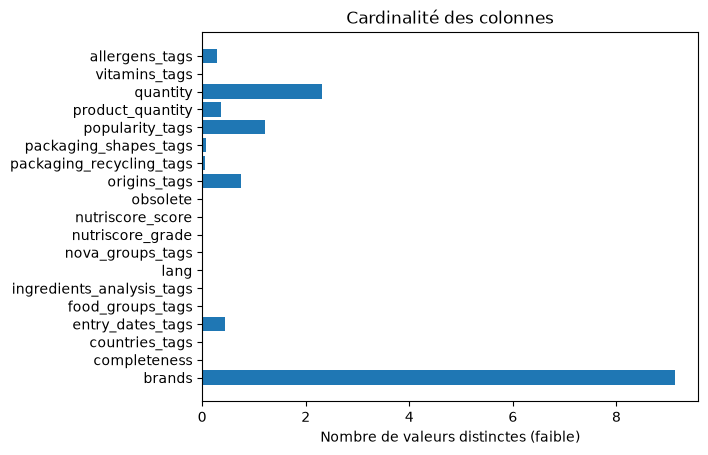

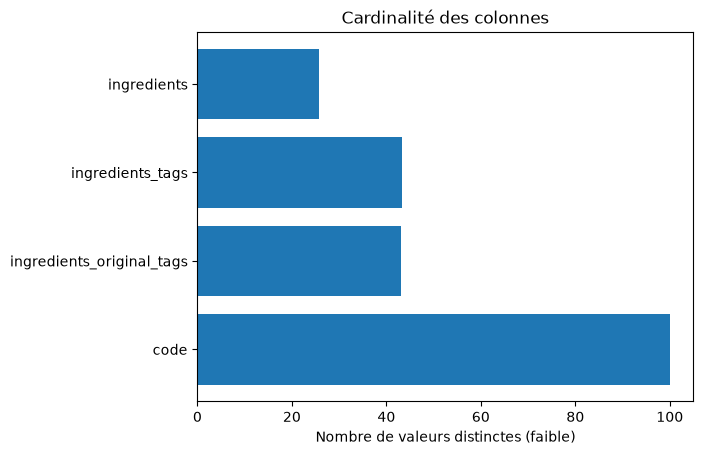

In [11]:
from matplotlib.ticker import FuncFormatter

# def format_number(x, pos):
#     if x >= 1_000_000:
#         return f"{x / 1_000_000:.1f}M"
#     if x >= 1_000:
#         return f"{x / 1_000:.0f}k"
#     return f"{x:.0f}"

colonnes = []
cardinalites = []
for name, count, df, ratio in distri_and_cardinality_output:
    if ratio == 0.0:
        colonnes.append(name)
        cardinalites.append(count / total_product * 100.0)

markdown = "# Profiling des colonnes\n\n"
for name, count, df, ratio in distri_and_cardinality_output:
    markdown += f"## {name}\n\n"
    if ratio == 0.0:
        markdown += f"- **Cardinalité :** {count}\n\n"
    else:
        markdown += f"- **Cardinalité des valeurs extraites :** {count}\n"
        markdown += "- **Type :** sous-colonne issue d'une structure imbriquée\n\n"

    markdown += "| Valeur | Distribution |\n"
    markdown += "|---|---:|\n"

    for value, percent in df.items():
        markdown += f"| {value} | {percent:.2f} % |\n"

    markdown += "\n"

print(markdown)
with open("profiling.md", "w", encoding="utf-8") as f:
    f.write(markdown)

mini = [(name, card) for name, card in zip(colonnes, cardinalites) if card < 10]
big = [(name, card) for name, card in zip(colonnes, cardinalites) if card >= 10.0]

plt.barh([x[0] for x in mini], [x[1] for x in mini])
# plt.gca().xaxis.set_major_formatter(FuncFormatter(format_number))
plt.xlabel("Nombre de valeurs distinctes (faible)")
plt.title("Cardinalité des colonnes")
plt.show()

plt.barh([x[0] for x in big], [x[1] for x in big])
# plt.gca().xaxis.set_major_formatter(FuncFormatter(format_number))
plt.xlabel("Nombre de valeurs distinctes (faible)")
plt.title("Cardinalité des colonnes")
plt.show()

    # print(df)

In [ ]:
# Profiling
for d_c in distri_and_cardinality_col:
    if d_c not in distri_and_cardinality_dict:
        start = time.time()

        # On ne lit plus que la colonne à analyser
        tmp = pd.read_parquet(food_parquet, columns=[d_c])
        # On applique le masque déjà calculé
        tmp = tmp.loc[mask]

        print(f"{d_c} -> {tmp[d_c].dtype} " f"({time.time() - start:.2f} s)")

        # Cardinalité + distribution
        counts = tmp[d_c].value_counts()
        distri_and_cardinality_output.append((d_c, len(counts), (counts / counts.sum() * 100).head(5)))

        distri_and_cardinality_dict[d_c] = 1